## Sales Prediction using Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Advertising.csv')

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [8]:
df = df.drop('Unnamed: 0',axis=1)

In [9]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

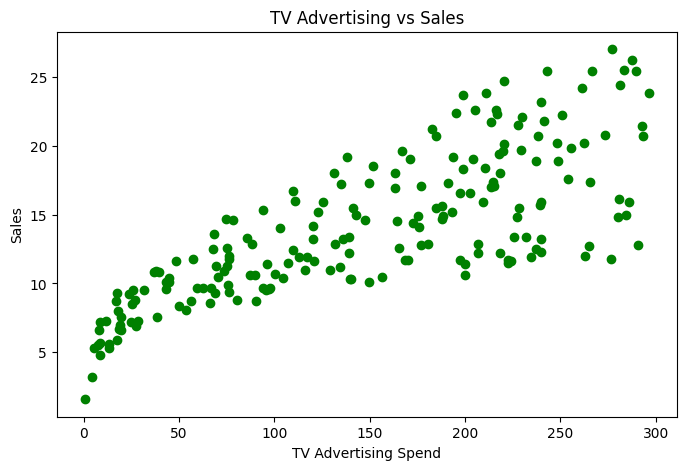

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['TV'],df['Sales'],color = 'green')
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

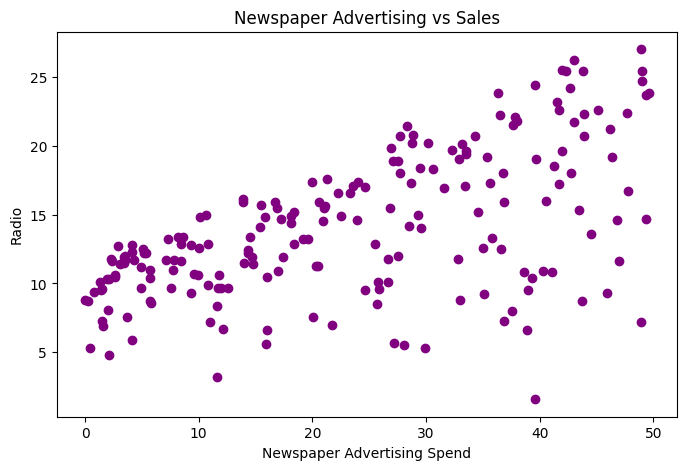

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['Radio'],df['Sales'],color = 'purple')
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Radio")
plt.title("Newspaper Advertising vs Sales")

plt.show()

In [14]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


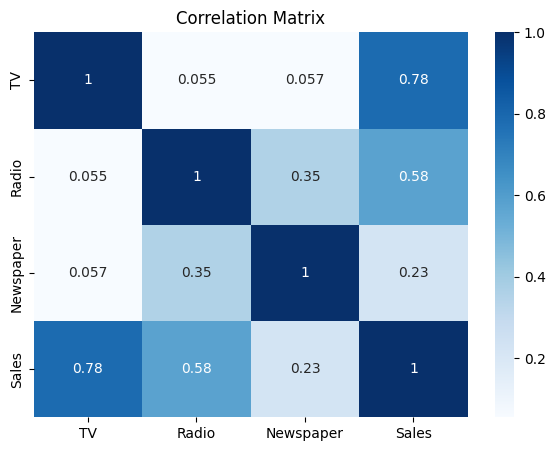

In [15]:
plt.figure(figsize = (7,5))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [16]:
X = df.drop(['Sales'],axis=1)
y=df['Sales']

In [17]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [19]:
print(X_train.shape)
print(X_test.shape)

(160, 3)
(40, 3)


In [20]:
from sklearn.linear_model  import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [23]:
comparison = pd.DataFrame({ "Actual Sales": y_test.values,"Predicted Sales": y_pred})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Absolute Error: 1.4607567168117606
Mean Squared Error: 3.174097353976104
R2 Score: 0.899438024100912


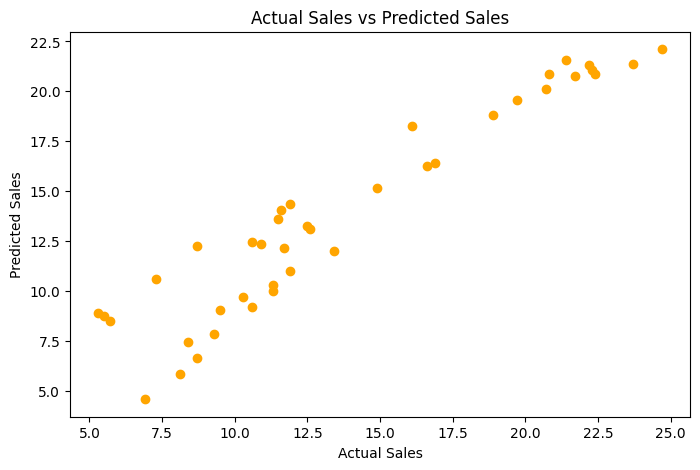

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,color= 'orange')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")

plt.show()

In [26]:
coefficients = pd.DataFrame({ "Feature": X.columns,"Coefficient": model.coef_})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


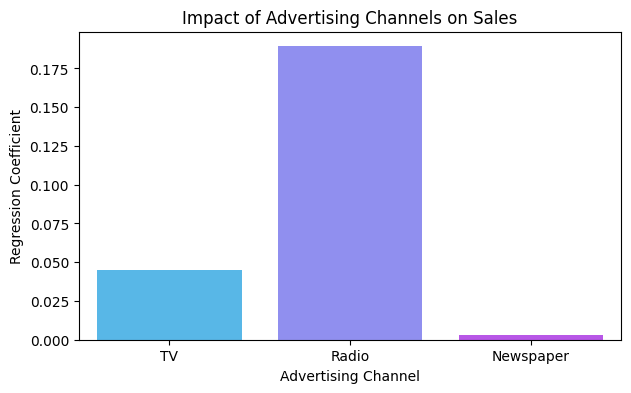

In [27]:
plt.figure(figsize=(7,4))

sns.barplot( x="Feature", y="Coefficient", data=coefficients,palette="cool")
plt.title("Impact of Advertising Channels on Sales")
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")
plt.show()

In [28]:
new_advertising = [[200, 40, 30]]
predicted_sales = model.predict(new_advertising)
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 19.575606431481972


### Analysis
Business Insights
Advertising expenditure has a positive relationship with sales.
TV and Radio advertising can be important contributors to sales prediction.
Advertising budgets can be allocated toward channels that show stronger relationships with sales.
The regression model can be used to estimate expected sales for a proposed advertising budget.
Businesses can use these predictions to make more informed marketing budget decisions.